In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [7]:
df = pd.read_csv('data/egx/ADIB.csv')

In [8]:
df

,date,open,high,low,close,volume
0,2015-01-04,5.593474,5.623873,5.487076,5.525075,66572
1,2015-01-05,5.525075,5.585874,5.494676,5.540275,134413
2,2015-01-06,5.540275,5.905067,5.395878,5.684672,819828
3,2015-01-08,5.684672,5.920266,5.745470,5.851868,178064
4,2015-01-11,5.851868,5.920266,5.578274,5.715071,322329
...,...,...,...,...,...,...
2856,2026-07-26,49.299999,49.200001,48.619999,49.119999,702720
2857,2026-07-27,49.119999,51.950001,49.009998,51.490002,5301528
2858,2026-07-28,51.490002,52.880001,51.200001,52.150002,2312301
2859,2026-07-29,52.150002,52.869999,51.619999,52.110001,1998460


In [9]:
df['MA9'] = df['close'].rolling(9).mean()
df['MA20'] = df['close'].rolling(20).mean()

In [10]:
cash = 1000
position = 0
portfolio_values = []
buy_count = 0
sell_count = 0

for i in range(len(df)):
    
    price = df['close'].iloc[i]
    ma9 = df['MA9'].iloc[i]
    ma20 = df['MA20'].iloc[i]

    
    if np.isnan(ma9) or np.isnan(ma20):
        portfolio_values.append(cash)
        continue
    
    if ma9 > ma20 and position == 0:
        position = cash / price
        cash = 0
        buy_count += 1
    
    elif ma9 < ma20 and position > 0:
        cash = position * price
        position = 0
        sell_count += 1
    
    total_value = cash + position * price
    portfolio_values.append(total_value)

In [11]:
final_value = portfolio_values[-1]
print("Final Portfolio Value:", final_value)

Final Portfolio Value: 2464.177286429078


In [12]:
portfolio_series = pd.Series(portfolio_values, index=df.index)

rolling_max = portfolio_series.cummax()
drawdown = (portfolio_series - rolling_max) / rolling_max

max_drawdown = drawdown.min()
print("Max Drawdown:", max_drawdown)

Max Drawdown: -0.6608252301312404


In [13]:
print("Buy", buy_count)
print("Sell", sell_count)

Buy 78
Sell 77


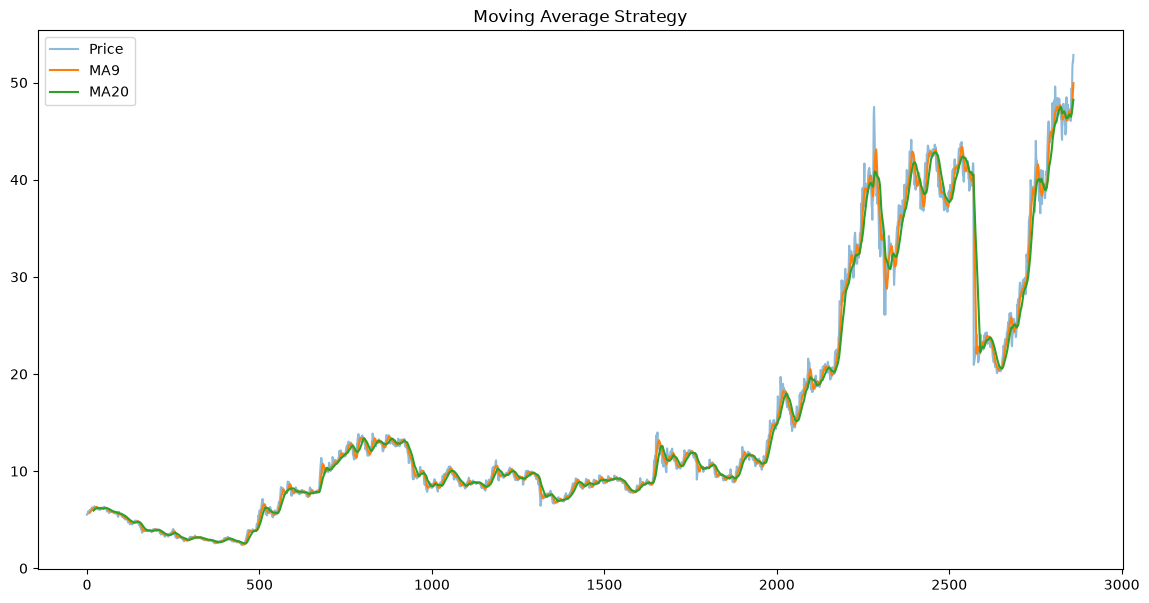

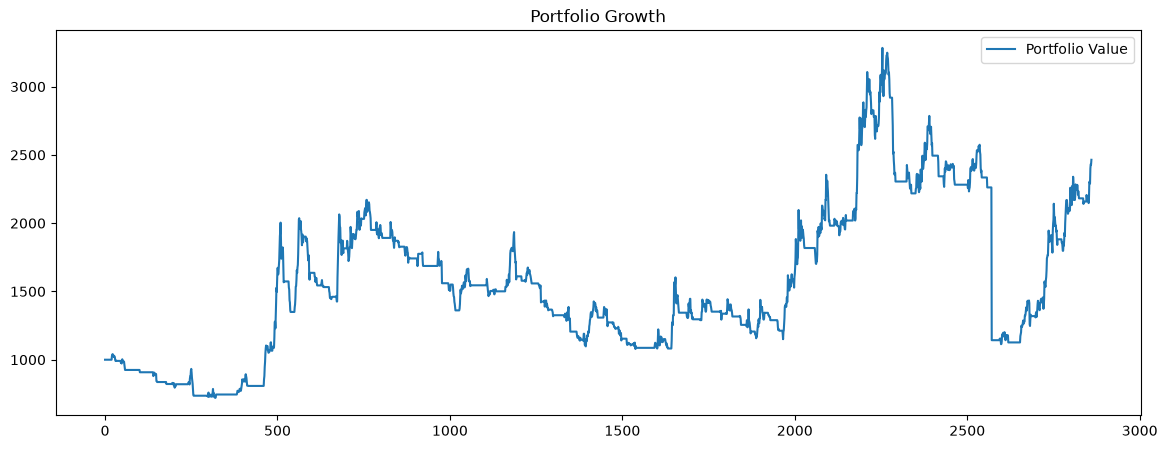

In [14]:
plt.figure(figsize=(14,7))

plt.plot(df.index, df['close'], label='Price', alpha=0.5)
plt.plot(df.index, df['MA9'], label='MA9')
plt.plot(df.index, df['MA20'], label='MA20')

plt.title("Moving Average Strategy")
plt.legend()
plt.show()

plt.figure(figsize=(14,5))
plt.plot(portfolio_series, label='Portfolio Value')
plt.title("Portfolio Growth")
plt.legend()
plt.show()

In [15]:
# ===== Performance Overview =====

print("Initial Cash:", initial_cash)
print("Final Portfolio Value:", portfolio_values[-1])

total_return = (portfolio_values[-1] - initial_cash) / initial_cash
print("Total Return:", total_return)

Initial Cash: 1000
Final Portfolio Value: 2464.177286429078
Total Return: 1.4641772864290779


In [16]:
# ===== Performance Overview =====

print("Initial Cash:", initial_cash)
print("Final Portfolio Value:", portfolio_values[-1])

total_return = (portfolio_values[-1] - initial_cash) / initial_cash
print("Total Return:", total_return)

Initial Cash: 1000
Final Portfolio Value: 2464.177286429078
Total Return: 1.4641772864290779


In [17]:
# ===== Return Quality =====

returns = portfolio_series.pct_change().dropna()

print("Average Return:", returns.mean())
print("Return Std (Volatility):", returns.std())

Average Return: 0.0005445474614324536
Return Std (Volatility): 0.020418743880588012


<Axes: title={'center': 'Portfolio Performance'}>

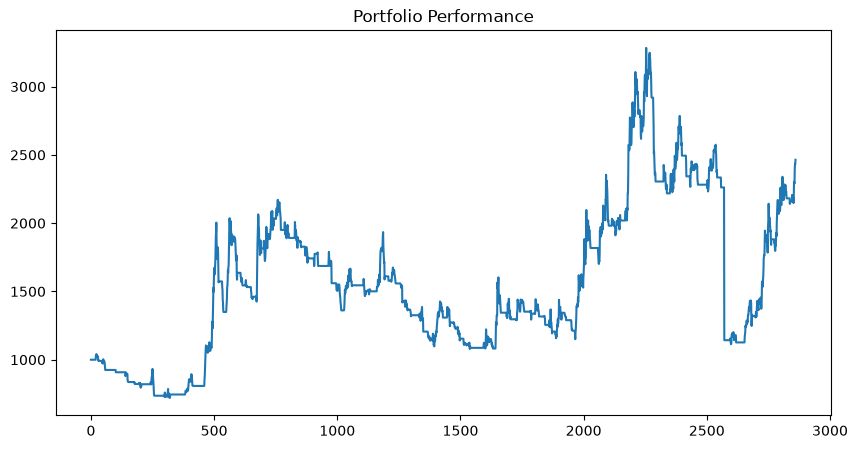

In [18]:
# ===== Equity Curve =====

portfolio_series.plot(title="Portfolio Performance", figsize=(10,5))